First model with one hidden layer:
Epoch [1/10], Loss: 0.5171
Epoch [2/10], Loss: 0.3958
Epoch [3/10], Loss: 0.3576
Epoch [4/10], Loss: 0.3300
Epoch [5/10], Loss: 0.3133
Epoch [6/10], Loss: 0.2967
Epoch [7/10], Loss: 0.2834
Epoch [8/10], Loss: 0.2746
Epoch [9/10], Loss: 0.2637
Epoch [10/10], Loss: 0.2547
Test accuracy: 87.49%

Second model with two hidden layers:
Epoch [1/10], Loss: 0.5395
Epoch [2/10], Loss: 0.3982
Epoch [3/10], Loss: 0.3569
Epoch [4/10], Loss: 0.3296
Epoch [5/10], Loss: 0.3116
Epoch [6/10], Loss: 0.2937
Epoch [7/10], Loss: 0.2816
Epoch [8/10], Loss: 0.2711
Epoch [9/10], Loss: 0.2614
Epoch [10/10], Loss: 0.2543
Test accuracy: 88.53%

Third model with three hidden layers:
Epoch [1/10], Loss: 0.5750
Epoch [2/10], Loss: 0.4005
Epoch [3/10], Loss: 0.3651
Epoch [4/10], Loss: 0.3386
Epoch [5/10], Loss: 0.3179
Epoch [6/10], Loss: 0.3057
Epoch [7/10], Loss: 0.2886
Epoch [8/10], Loss: 0.2814
Epoch [9/10], Loss: 0.2709
Epoch [10/10], Loss: 0.2656
Test accuracy: 88.33%



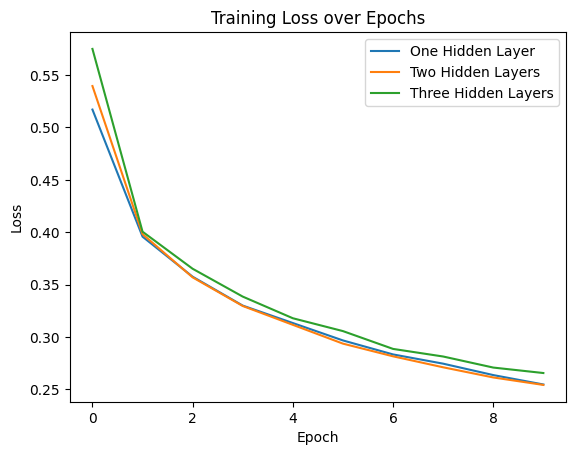

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# DataLoader: Remember, this is efficient for larger datasets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Model definition

# First model definition (one hidden layer)
class FashionClassifier1(nn.Module):
    def __init__(self):
        super(FashionClassifier1, self).__init__()
        self.flatten = nn.Flatten() # Flatten layer to convert 2D images to 1D vectors
        self.fc1 = nn.Linear(28*28, 128) # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 10) # Output layer to 10 classes
        self.relu = nn.ReLU() # Activation function
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Second model definition (two hidden layers)
class FashionClassifier2(nn.Module):
    def __init__(self):
        super(FashionClassifier2, self).__init__()
        self.flatten = nn.Flatten() # Flatten layer to convert 2D images to 1D vectors
        self.fc1 = nn.Linear(28*28, 128)  # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 64)       # Additional hidden layer
        self.fc3 = nn.Linear(64, 10)       # Output layer to 10 classes
        self.relu = nn.ReLU() # Activation function
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

# Third model definition (three hidden layers)
class FashionClassifier3(nn.Module):
    def __init__(self):
        super(FashionClassifier3, self).__init__()
        self.flatten = nn.Flatten() # Flatten layer to convert 2D images to 1D vectors
        self.fc1 = nn.Linear(28*28, 128)  # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 64)       # Additional hidden layer
        self.fc3 = nn.Linear(64, 32)       # Additional hidden layer
        self.fc4 = nn.Linear(32, 10)       # Output layer to 10 classes
        self.relu = nn.ReLU() # Activation function
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

model1 = FashionClassifier1()
model2 = FashionClassifier2()
model3 = FashionClassifier3()

# 3. Optimization and loss function
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-4)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
optimizer3 = optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)

# 4. Training loop
loss_history1, loss_history2, loss_history3 = [], [], []

# First model
print('First model with one hidden layer:')
for epoch in range(10):
    model1.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer1.zero_grad()  # 1. Zero the gradients
        outputs = model1(images) # 2. Forward pass
        loss = criterion(outputs, labels) # 3. Calculate loss
        loss.backward() # 4. Backward pass
        optimizer1.step() # 5. Optimizer step
        running_loss += loss.item()
    
    avg_loss1 = running_loss / len(train_loader)
    loss_history1.append(avg_loss1)
    print(f'Epoch [{epoch+1}/10], Loss: {avg_loss1:.4f}')


model1.eval()
correct1 = 0
total1 = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model1(images)
        _, predicted = torch.max(outputs, 1)
        total1 += labels.size(0)
        correct1 += (predicted == labels).sum().item()

accuracy1 = correct1 / total1
print(f'Test accuracy: {accuracy1:.2%}\n')


# Second model
print('Second model with two hidden layers:')
for epoch in range(10):
    model2.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer2.zero_grad()  # 1. Zero the gradients
        outputs = model2(images) # 2. Forward pass
        loss = criterion(outputs, labels) # 3. Calculate loss
        loss.backward() # 4. Backward pass
        optimizer2.step() # 5. Optimizer step
        running_loss += loss.item()
    
    avg_loss2 = running_loss / len(train_loader)
    loss_history2.append(avg_loss2)
    print(f'Epoch [{epoch+1}/10], Loss: {avg_loss2:.4f}')

model2.eval()
correct2 = 0
total2 = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        total2 += labels.size(0)
        correct2 += (predicted == labels).sum().item()

accuracy2 = correct2 / total2
print(f'Test accuracy: {accuracy2:.2%}\n')

# Third model
print('Third model with three hidden layers:')
for epoch in range(10):
    model3.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer3.zero_grad()  # 1. Zero the gradients
        outputs = model3(images) # 2. Forward pass
        loss = criterion(outputs, labels) # 3. Calculate loss
        loss.backward() # 4. Backward pass
        optimizer3.step() # 5. Optimizer step
        running_loss += loss.item()
    
    avg_loss3 = running_loss / len(train_loader)
    loss_history3.append(avg_loss3)
    print(f'Epoch [{epoch+1}/10], Loss: {avg_loss3:.4f}')

model3.eval()
correct3 = 0
total3 = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model3(images)
        _, predicted = torch.max(outputs, 1)
        total3 += labels.size(0)
        correct3 += (predicted == labels).sum().item()

accuracy3 = correct3 / total3
print(f'Test accuracy: {accuracy3:.2%}\n')

# 5. Visualization
plt.plot(loss_history1, label='One Hidden Layer')
plt.plot(loss_history2, label='Two Hidden Layers')
plt.plot(loss_history3, label='Three Hidden Layers')
plt.legend()
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()